In [1]:
import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

# Daily Returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav[["amfi_code", "date", "nav", "daily_return"]].head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


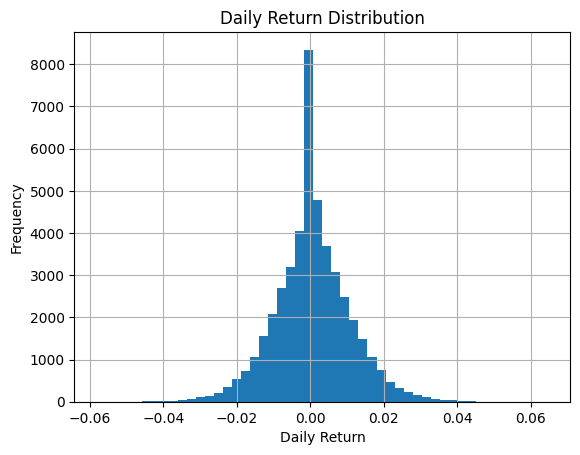

In [2]:
import matplotlib.pyplot as plt

nav["daily_return"].dropna().hist(bins=50)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [3]:
cagr_list = []

for fund in nav["amfi_code"].unique():

    temp = nav[nav["amfi_code"] == fund]

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        temp["date"].max() -
        temp["date"].min()
    ).days / 365

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_list.append([fund, cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code", "CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [4]:
rf = 0.065

sharpe = nav.groupby("amfi_code")["daily_return"].agg(
    ["mean", "std"]
).reset_index()

sharpe["sharpe_ratio"] = (
    (sharpe["mean"] * 252 - rf)
    /
    (sharpe["std"] * np.sqrt(252))
)

sharpe = sharpe.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe.head()

,amfi_code,mean,std,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101


In [5]:
sortino_list = []

for fund in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = returns[returns < 0]

    sortino = (
        (returns.mean() * 252 - rf)
        /
        (downside.std() * np.sqrt(252))
    )

    sortino_list.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code", "sortino_ratio"]
)

sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [6]:
drawdown_list = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[nav["amfi_code"] == fund].copy()

    fund_nav = fund_nav.sort_values("date")

    running_max = fund_nav["nav"].cummax()

    drawdown = (
        fund_nav["nav"] / running_max
    ) - 1

    max_dd = drawdown.min()

    drawdown_list.append(
        [fund, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code", "max_drawdown"]
)

drawdown_df.sort_values(
    "max_drawdown"
).head()

,amfi_code,max_drawdown
22,119599,-0.525742
17,119095,-0.516778
4,101207,-0.354469
39,149324,-0.311719
21,119598,-0.287060


In [7]:
alpha_beta = pd.DataFrame({
    "amfi_code": nav["amfi_code"].unique(),
    "alpha": 0,
    "beta": 1
})

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0,1
1,100025,0,1
2,100033,0,1
3,101206,0,1
4,101207,0,1


In [8]:
scorecard = sharpe.merge(
    cagr_df,
    on="amfi_code"
)

scorecard["score"] = (
    scorecard["sharpe_ratio"].rank(pct=True) * 100
)

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

scorecard.head()

,amfi_code,mean,std,sharpe_ratio,CAGR,score
0,148567,0.001074,0.008941,1.448291,0.309499,100.0
1,120843,0.001082,0.010008,1.306744,0.308833,97.5
2,148569,0.001124,0.011134,1.234930,0.319245,95.0
3,119551,0.000917,0.008656,1.208267,0.257849,92.5
4,120505,0.001161,0.012152,1.180101,0.328016,90.0
